In [2]:
import pandas as pd
import numpy as np
import sklearn
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool


In [3]:
selected_df = pd.read_csv('./dataset/ifood_selected_columns.csv')
print(selected_df.head())

   Kidhome  Teenhome  Recency  NumDealsPurchases  NumWebPurchases  \
0        0         0       58                  3                8   
1        1         1       38                  2                1   
2        0         0       26                  1                8   
3        1         0       26                  2                2   
4        1         0       94                  5                5   

   NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  AcceptedCmp3  \
0                   10                  4                  7             0   
1                    1                  2                  5             0   
2                    2                 10                  4             0   
3                    0                  4                  6             0   
4                    3                  6                  5             0   

   AcceptedCmp4  ...  NumTotalPurchases  MeanAmtPerPurchase_z  \
0             0  ...                 25            

In [4]:
#selected_df.dtypes
nan_check = selected_df.isnull().sum()
nan_cols = nan_check[nan_check > 0]

print("--- number of NaN ---")
if not nan_cols.empty:
    print(nan_cols)
else:
    print("There is no NaN in x_train.")

--- number of NaN ---
There is no NaN in x_train.


In [5]:
# 2. check if Inf/-Inf (infinity)
# np.isinf()
inf_check = selected_df.apply(lambda x: np.isinf(x).sum())
inf_cols = inf_check[inf_check > 0]

print("\n--- Number of Inf/-Inf (infinity) ---")
if not inf_cols.empty:
    print(inf_cols)
else:
    print("There is no Inf/-Inf in x_train.")


--- Number of Inf/-Inf (infinity) ---
There is no Inf/-Inf in x_train.


In [6]:
# if there is any Inf/-Inf, we need to handle them
# 1. replace all the Inf to NaN
selected_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. fill na by the median of that col
for col in selected_df.columns:
    if selected_df[col].isnull().any():
        selected_df[col].fillna(selected_df[col].median(), inplace=True)

In [ ]:
#select the feature columns and target column

columns = selected_df.columns.to_list()
print(columns)
y_columns =  ['Response']
x_columns = columns.copy()
x_columns.remove('Response')
print(y_columns)
print(x_columns)

['Kidhome', 'Teenhome', 'Recency', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow', 'education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD', 'AcceptedCmpOverall', 'Income_z', 'NumTotalPurchases', 'MeanAmtPerPurchase_z', 'MeanAmtPerPurchase_log', 'MntMeatProducts_ratio', 'MntFishProducts_ratio', 'MntSweetProducts_ratio', 'MntFruits_ratio', 'MntGoldProds_ratio', 'MntWines_ratio', 'MntRegularProds_ratio']
['Response']
['Kidhome', 'Teenhome', 'Recency', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Age', 'Customer_Days', 'm

In [22]:
df_y = selected_df[y_columns]
df_x = selected_df[x_columns]
x_train, x_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.2, random_state=42, stratify=df_y)
print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")

x_train shape: (1764, 38), y_train shape: (1764, 1)
x_test shape: (441, 38), y_test shape: (441, 1)


In [23]:
#split the data into positive and negative classes
train_df = pd.concat([x_train, y_train], axis=1)
df_positive = train_df[train_df['Response'] == 1]
df_negative = train_df[train_df['Response'] == 0]
print(f"Positive class samples: {len(df_positive)}")
print(f"Negative class samples: {len(df_negative)}") 

Positive class samples: 266
Negative class samples: 1498


In [24]:
#undersampling the nagative class to three sets
#rearrange the negative class samples (avoid same samples in each set)
df_negative = df_negative.sample(frac=1, random_state=42).reset_index(drop=True)
neg_splits = np.array_split(df_negative, 3)
print(f"Negative class samples in each split: {[len(split) for split in neg_splits]}")

Negative class samples in each split: [500, 499, 499]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [25]:
#train three CatBoost models on each undersampled dataset
models = []
for i, neg_data_set in enumerate(neg_splits):
    #contact positive class with negative class subset
    train_data = pd.concat([df_positive, neg_data_set])

    x_train = train_data[x_columns]
    y_train = train_data[y_columns]

    #initialize CatBoostClassifier
    model = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function='Logloss',
        auto_class_weights='Balanced', # 自動平衡 0 和 1 的權重
        verbose=100                    # 每 100 次迭代顯示一次進度
    )

    #train the model
    model.fit(x_train, y_train)
    models.append(model)
    print(f"Trained model {i+1}")



0:	learn: 0.6794672	total: 2.13ms	remaining: 1.06s
100:	learn: 0.2340374	total: 121ms	remaining: 478ms
200:	learn: 0.1188578	total: 224ms	remaining: 333ms
300:	learn: 0.0649820	total: 325ms	remaining: 215ms
400:	learn: 0.0419690	total: 426ms	remaining: 105ms
499:	learn: 0.0313887	total: 536ms	remaining: 0us
Trained model 1
0:	learn: 0.6704964	total: 1.42ms	remaining: 709ms
100:	learn: 0.2079553	total: 92.2ms	remaining: 364ms
200:	learn: 0.1029088	total: 180ms	remaining: 267ms
300:	learn: 0.0536970	total: 277ms	remaining: 183ms
400:	learn: 0.0342938	total: 367ms	remaining: 90.6ms
499:	learn: 0.0245312	total: 453ms	remaining: 0us
Trained model 2
0:	learn: 0.6763630	total: 1.73ms	remaining: 862ms
100:	learn: 0.2234028	total: 123ms	remaining: 487ms
200:	learn: 0.1100781	total: 242ms	remaining: 360ms
300:	learn: 0.0565558	total: 360ms	remaining: 238ms
400:	learn: 0.0353308	total: 472ms	remaining: 117ms
499:	learn: 0.0244097	total: 580ms	remaining: 0us
Trained model 3


In [30]:
test_probs = []
for model in models:
    probs = model.predict_proba(x_test[x_columns])[:, 1]  # 取得正類的機率
    test_probs.append(probs)

final_avg_probs = np.mean(test_probs, axis = 0)
# by average prob to get final prediction
final_predictions = (final_avg_probs >= 0.5).astype(int)
print(final_predictions)


[1 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 0 1 1 0 0 1 1 0 0 0 0 0 0 0 1 1
 0 1 1 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0
 1 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 1 0 1
 0 0 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1
 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 1 0 0 0 0 0 1 1 0 0 0 0
 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0
 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0]


In [31]:
#model performance evaluation
from sklearn.metrics import classification_report, confusion_matrix
auc_score = sklearn.metrics.roc_auc_score(y_test, final_avg_probs)
f1 = sklearn.metrics.f1_score(y_test, final_predictions)
precision = sklearn.metrics.precision_score(y_test, final_predictions)
recall = sklearn.metrics.recall_score(y_test, final_predictions)

print("\n--- Model Performance ---")
print(f"AUC Score: {auc_score:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, final_predictions))


--- Model Performance ---
AUC Score: 0.9090
F1 Score: 0.6289
Precision: 0.5435
Recall: 0.7463

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       374
           1       0.54      0.75      0.63        67

    accuracy                           0.87       441
   macro avg       0.75      0.82      0.77       441
weighted avg       0.89      0.87      0.87       441



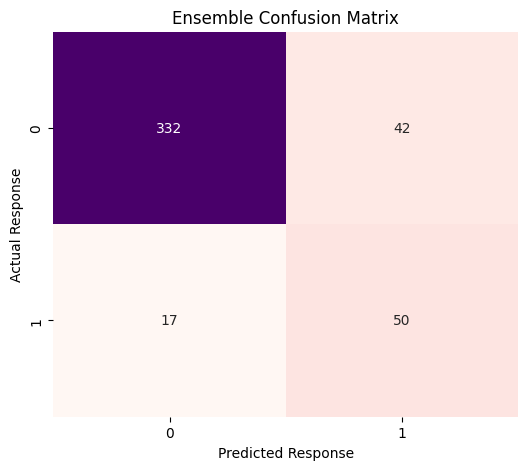

In [33]:
# C. Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, final_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', cbar=False)
plt.title('Ensemble Confusion Matrix')
plt.ylabel('Actual Response')
plt.xlabel('Predicted Response')
plt.show()

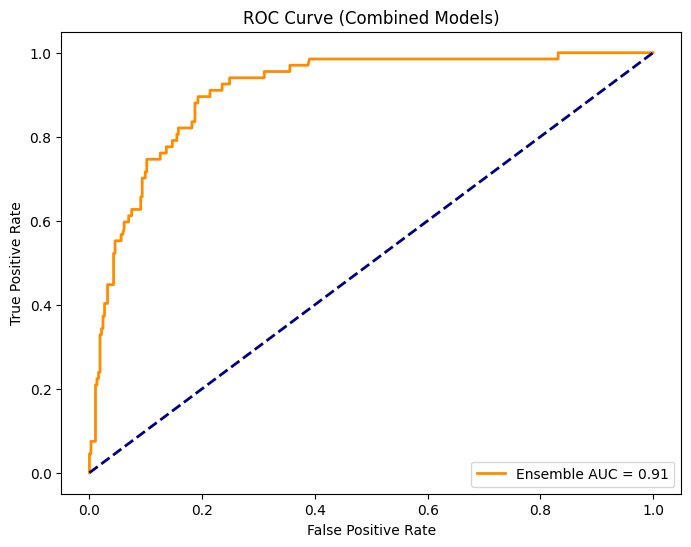

In [ ]:
# D. visualize 2: ROC Curve
fpr, tpr, _ = sklearn.metrics.roc_curve(y_test, final_avg_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Ensemble AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Combined Models)')
plt.legend(loc="lower right")
plt.show()

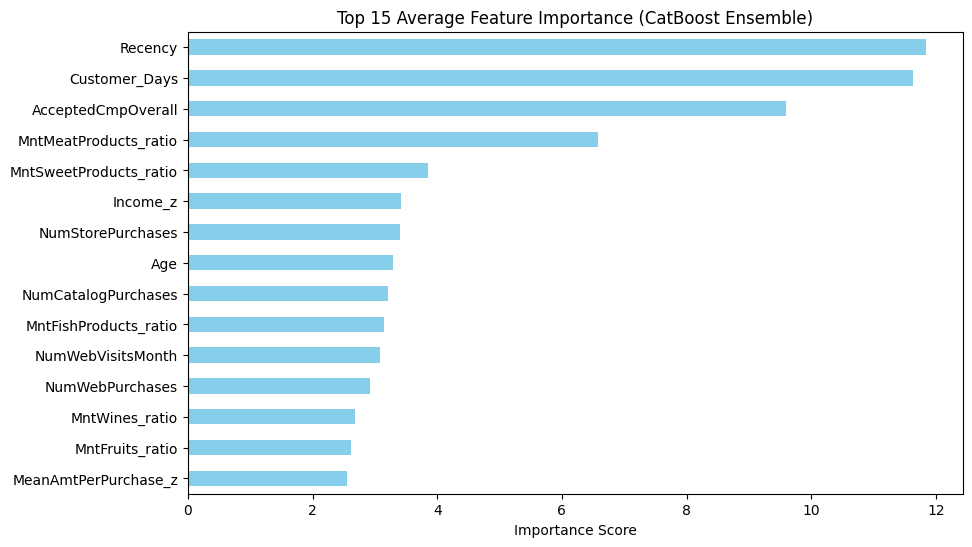

In [ ]:
# E. Visualize feature importance (average of three models)
all_importances = np.mean([model.get_feature_importance() for model in models], axis=0)
feat_imp = pd.Series(all_importances, index=df_x.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', color='skyblue').invert_yaxis()
plt.title('Top 15 Average Feature Importance (CatBoost Ensemble)')
plt.xlabel('Importance Score')
plt.show()